In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
AZ = pd.read_excel('Amazon2023.xlsx')
AZ.head()

,ITEM,CATEGORY,LISTED PRICE,PRICE with Tax,DATE PURCHASED,Month_Num,TOTAL SPENT CATEGORY
0,Mouth Masks,Health,7.99,8.48,2023-02-01,2,65.48
1,Bamboo Toothbrushes,Health,6.99,7.48,2023-02-02,2,65.48
2,Earbuds,Electronic,11.99,12.50,2023-02-02,2,178.00
3,Phone Chargers,Electronic,14.97,15.35,2023-02-02,2,178.00
4,Multi-Charging Cable,Electronic,7.99,8.48,2023-02-06,2,178.00


In [3]:
#check for missing data and duplicates
print("Missing values:\n", AZ.isnull().sum())
print("\nDuplicate rows:", AZ.duplicated().sum())

Missing values:
 ITEM                    0
CATEGORY                0
LISTED PRICE            0
PRICE with Tax          0
DATE PURCHASED          0
Month_Num               0
TOTAL SPENT CATEGORY    0
dtype: int64

Duplicate rows: 0


In [4]:
#  Clean up dates and prices
AZ['DATE PURCHASED'] = pd.to_datetime(AZ['DATE PURCHASED'])
AZ['PRICE with Tax'] = pd.to_numeric(AZ['PRICE with Tax'], errors='coerce')


In [5]:
# 3. Financial Summary
total_spent = AZ['PRICE with Tax'].sum()
avg_item_cost = AZ['PRICE with Tax'].mean()
total_items = len(AZ)

print(f"--- 2023 Amazon Purchase Summary ---")
print(f"Total Spent: ${total_spent:,.2f}")
print(f"Total Items Bought: {total_items}")
print(f"Average Cost Per Item: ${avg_item_cost:,.2f}\n")

--- 2023 Amazon Purchase Summary ---
Total Spent: $548.84
Total Items Bought: 38
Average Cost Per Item: $14.44



In [6]:
# 4. Spending by Category
print("--- Top Categories by Spending ---")
category_spend = AZ.groupby('CATEGORY')['PRICE with Tax'].sum().sort_values(ascending=False)
print(category_spend.head())

--- Top Categories by Spending ---
CATEGORY
Electronic    178.00
Home          109.80
Outdoor        88.55
Health         65.48
Kitchen        47.01
Name: PRICE with Tax, dtype: float64


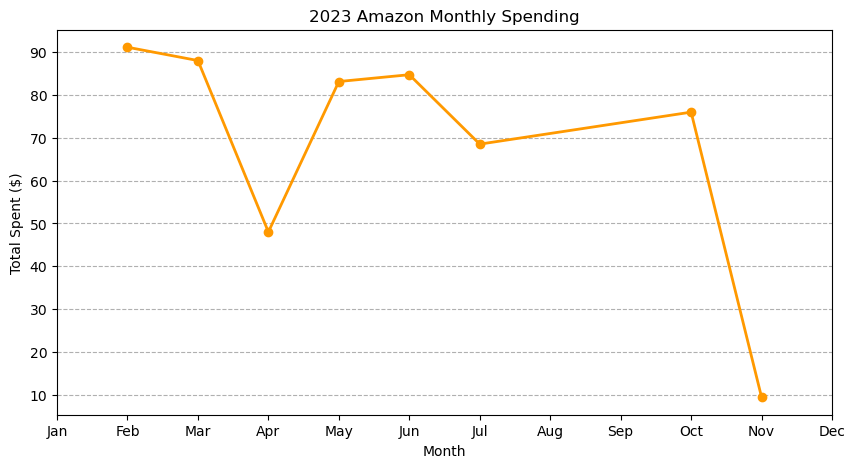

In [7]:
# 5. Plot Monthly Spending Timeline
AZ['Month_Num'] = AZ['DATE PURCHASED'].dt.month
timeline = AZ.groupby('Month_Num')['PRICE with Tax'].sum()

plt.figure(figsize=(10, 5))
plt.plot(timeline.index, timeline.values, marker='o', color='#FF9900', linewidth=2)
plt.title('2023 Amazon Monthly Spending')
plt.xlabel('Month')
plt.ylabel('Total Spent ($)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--')
plt.show()
#Spending is the highest in Feburary and May through June which correaltes with Summer Outdoor purchases and holiday spending.

In [8]:
AZ['PRICE with Tax'] = pd.to_numeric(AZ['PRICE with Tax'], errors='coerce')

# 3. Create the new total spent category column
AZ['TOTAL SPENT CATEGORY'] = AZ.groupby('CATEGORY')['PRICE with Tax'].transform('sum')

# 4. Save the updated DataFrame back to your Excel file
AZ.to_excel('Amazon2023.xlsx', index=False)

print("Successfully added 'TOTAL SPENT CATEGORY' and updated the Excel file!")
AZ.head()


Successfully added 'TOTAL SPENT CATEGORY' and updated the Excel file!


,ITEM,CATEGORY,LISTED PRICE,PRICE with Tax,DATE PURCHASED,Month_Num,TOTAL SPENT CATEGORY
0,Mouth Masks,Health,7.99,8.48,2023-02-01,2,65.48
1,Bamboo Toothbrushes,Health,6.99,7.48,2023-02-02,2,65.48
2,Earbuds,Electronic,11.99,12.50,2023-02-02,2,178.00
3,Phone Chargers,Electronic,14.97,15.35,2023-02-02,2,178.00
4,Multi-Charging Cable,Electronic,7.99,8.48,2023-02-06,2,178.00


In [14]:
# Count items, total spend, and average cost per category
category_summary = AZ.groupby('CATEGORY').agg(
    Item_Count=('ITEM', 'count'),
    Total_Spent=('PRICE with Tax', 'sum'),
    Avg_Cost_Per_Item=('PRICE with Tax', 'mean')
).round(2).sort_values('Total_Spent', ascending=False)

print(category_summary)

            Item_Count  Total_Spent  Avg_Cost_Per_Item
CATEGORY                                              
Electronic          10       178.00              17.80
Home                 5       109.80              21.96
Outdoor              7        88.55              12.65
Health               6        65.48              10.91
Kitchen              3        47.01              15.67
Beauty               5        42.94               8.59
Office               1        12.48              12.48
Crafts               1         4.58               4.58


<Axes: title={'center': 'Average Cost per Item by Category'}, ylabel='CATEGORY'>

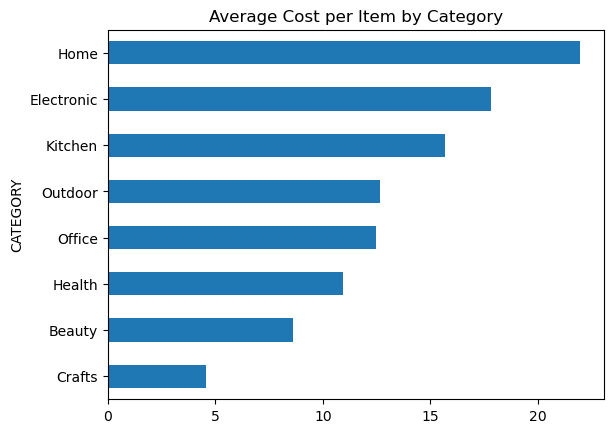

In [9]:
avg_by_cat = AZ.groupby('CATEGORY')['PRICE with Tax'].mean().sort_values()
avg_by_cat.plot(kind='barh', title='Average Cost per Item by Category')
#Insights
#“Electronics spending is high mainly because of volume (10 items), not necessarily high individual prices. 
#Home goods had the highest average cost per item ($21.96).”

In [10]:

# Sort categories by total spending
category_rank = AZ.groupby('CATEGORY')['PRICE with Tax'].sum().sort_values(ascending=False).to_frame()

# Calculate cumulative percentage
category_rank['CUMULATIVE_PERC'] = category_rank['PRICE with Tax'].cumsum() / category_rank['PRICE with Tax'].sum() * 100
print(category_rank)

### Insight: Electronics Top Spending
#- Electronics accounted for 32% of total spend, driven by **10 purchases** (highest volume category).
#- However, **Home** had higher average cost per item ($21.96 vs $17.80), suggesting larger individual investments.
#- Recommendation: Review if all 10 electronics were necessary, or if multi‑use alternatives exist.

            PRICE with Tax  CUMULATIVE_PERC
CATEGORY                                   
Electronic          178.00        32.432038
Home                109.80        52.437869
Outdoor              88.55        68.571897
Health               65.48        80.502514
Kitchen              47.01        89.067852
Beauty               42.94        96.891626
Office               12.48        99.165513
Crafts                4.58       100.000000


In [11]:
# Convert to datetime if you haven't already
AZ['DATE PURCHASED'] = pd.to_datetime(AZ['DATE PURCHASED'])

# Extract the day of the week (Monday, Tuesday, etc.)
AZ['DAY_OF_WEEK'] = AZ['DATE PURCHASED'].dt.day_name()

# Find which day sees the highest average order cost
weekday_spending = AZ.groupby('DAY_OF_WEEK')['PRICE with Tax'].mean().sort_values(ascending=False)


In [12]:
# Flag any purchase that is 3 standard deviations above your average item price
mean_price = AZ['PRICE with Tax'].mean()
std_price = AZ['PRICE with Tax'].std()
cutoff = mean_price + (3 * std_price)

anomalies = AZ[AZ['PRICE with Tax'] > cutoff]
print(f"Flagged {len(anomalies)} unusually large transactions.")
if len(anomalies) > 0:
    print("These high-value purchases were:")
    print(anomalies[['ITEM', 'PRICE with Tax']])
    print("Consider removing them for 'typical' spending analysis.")

Flagged 1 unusually large transactions.
These high-value purchases were:
         ITEM  PRICE with Tax
35  Tracefone           58.48
Consider removing them for 'typical' spending analysis.


In [13]:
import plotly.express as px

# Create an interactive scatter plot of purchases over time
fig = px.scatter(AZ, x='DATE PURCHASED', y='PRICE with Tax', 
                 color='CATEGORY', hover_data=['ITEM'],
                 title='Interactive 2023 Amazon Purchase Map')
fig.show()
